Current Signal: Bullish


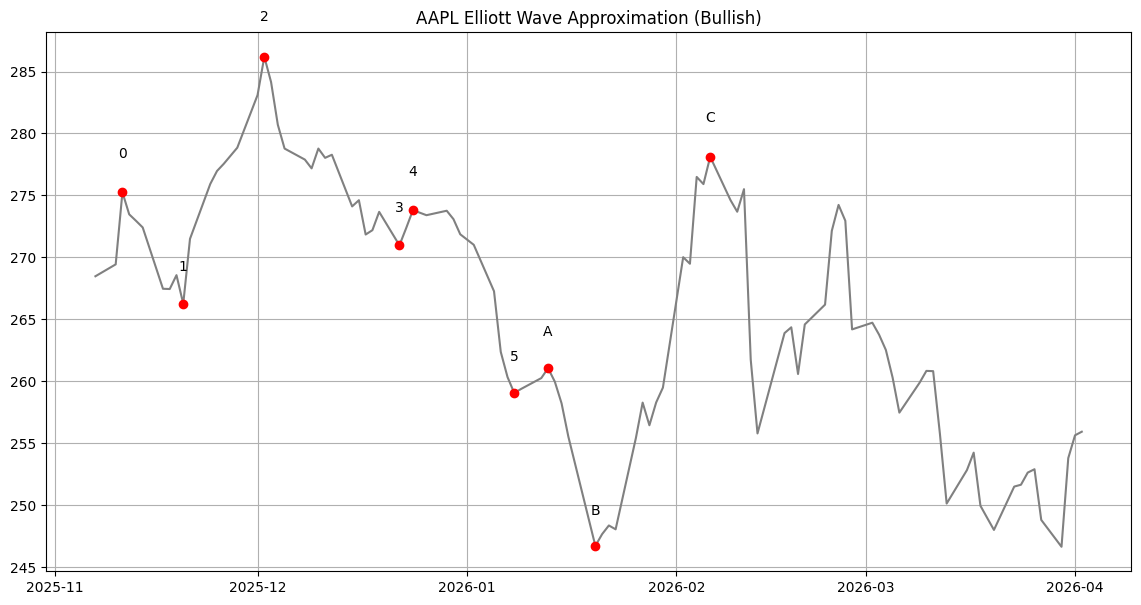

In [31]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import find_peaks
import numpy as np
from alpha_vantage.timeseries import TimeSeries

# -----------------------------
# Step 1: Setup API
# -----------------------------
API_KEY = "HVP1631QQ0BGFXE2"

symbol = "AAPL"

ts = TimeSeries(key=API_KEY, output_format='pandas')

# -----------------------------
# Step 2: Get data (FREE FIX)
# -----------------------------
data, meta = ts.get_daily(symbol=symbol, outputsize='compact')

# Clean columns
data.columns = ['open', 'high', 'low', 'close', 'volume']

# Sort oldest → newest
data = data.sort_index()

# -----------------------------
# Step 3: Extract prices
# -----------------------------
close_prices = data['close'].values
dates = data.index

# -----------------------------
# Step 4: Detect peaks/troughs
# -----------------------------
peaks, _ = find_peaks(close_prices, distance=5, prominence=2)
troughs, _ = find_peaks(-close_prices, distance=5, prominence=2)

wave_points = sorted(list(peaks) + list(troughs))[:9]
wave_labels = ['0', '1', '2', '3', '4', '5', 'A', 'B', 'C']

# -----------------------------
# Step 5: Signal detection
# -----------------------------
if len(wave_points) >= 2:
    last = wave_points[-1]
    prev = wave_points[-2]
    signal = "Bullish" if close_prices[last] > close_prices[prev] else "Bearish"
else:
    signal = "Neutral"

print(f"Current Signal: {signal}")

# -----------------------------
# Step 6: Plot
# -----------------------------
plt.figure(figsize=(14, 7))
plt.plot(dates, close_prices, color='gray')

for i, idx in enumerate(wave_points):
    plt.plot(dates[idx], close_prices[idx], 'ro')
    plt.text(dates[idx], close_prices[idx]*1.01, wave_labels[i], ha='center')

plt.title(f"{symbol} Elliott Wave Approximation ({signal})")
plt.grid(True)
plt.show()

In [34]:

last_idx = wave_points[-1]

if close_prices[last_idx] > close_prices[wave_points[-2]]:
    signal = "Bullish"
else:
    signal = "Bearish"

print("Current Signal:", signal)


Current Signal: Bullish
